Optimal Threshold Value: 100.0


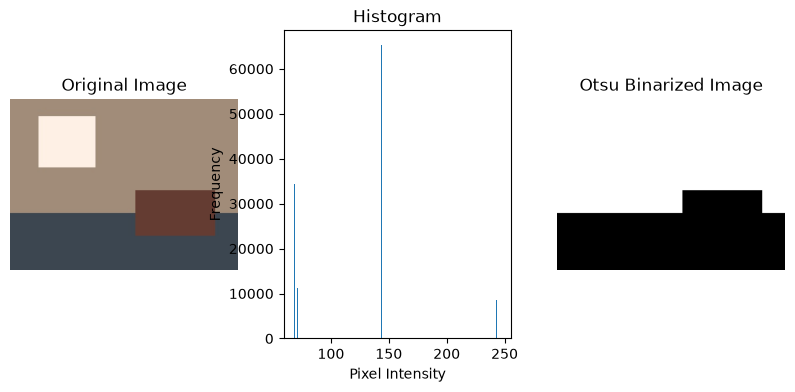

In [1]:
#OpenCV reads images in BGR
#Matplotlib expects RGB
#PROGRAM 2: Image Segmentation
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

try:
    from google.colab import files
    uploaded = files.upload()
    image_path = list(uploaded.keys())[0]
except Exception:
    if os.path.exists("room.jpg"):
        image_path = "room.jpg"
    elif os.path.exists("sample_data/room.jpg"):
        image_path = "sample_data/room.jpg"
    else:
        image_path = "lq.jpg"

# Read image in grayscale
img = cv2.imread(image_path, 0)
img_1 = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)
if img is None:
    raise ValueError("Failed to load image!")
# Apply Otsu's Binarization
# Threshold value is automatically calculated
#threshold(src, thresh, maxval, type)
threshold_value, binary_img = cv2.threshold(
    img,
    100,
    255,
    #cv2.THRESH_BINARY + cv2.THRESH_OTSU #---- for using OTSU
    cv2.THRESH_BINARY
    #v2.THRESH_BINARY_INV
)
print("Optimal Threshold Value:", threshold_value)
# Display results
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Histogram")
plt.hist(img.ravel(), 256)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1,3,3)
plt.title("Otsu Binarized Image")
plt.imshow(binary_img, cmap='gray')
plt.axis("off")

plt.show()
